# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**: Dataset diperoleh dari Kaggle: [Loan Default Prediction Dataset](https://www.kaggle.com/datasets/mdriadulislam/loan-default-prediction-dataset)
2. **Tujuan Dataset**: Memprediksi apakah seseorang akan gagal bayar (default) pinjaman berdasarkan karakteristik finansial dan demografis.
3. **Fitur**: monthly_income, monthly_expense, age, has_smartphone, has_wallet, avg_wallet_balance, on_time_payment_ratio, num_loans_taken
4. **Target**: target (0 = Tidak Default, 1 = Default)

# **2. Import Library**

Pada tahap ini, kita mengimpor pustaka Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from google.colab import files
import warnings
warnings.filterwarnings("ignore")

print("Library berhasil diimport")

Library berhasil diimport


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset ke dalam notebook dan memeriksa strukturnya.

In [7]:
from google.colab import files
print("Silakan upload file data_for_training.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"Data loaded from: {filename}")
print(f"Shape dataset: {df.shape}")
print("\n5 baris pertama:")
df.head()

Silakan upload file data_for_training.csv


Saving data_for_training.csv to data_for_training.csv
Data loaded from: data_for_training.csv
Shape dataset: (2019, 9)

5 baris pertama:


,monthly_income,monthly_expense,age,has_smartphone,has_wallet,avg_wallet_balance,on_time_payment_ratio,num_loans_taken,target
0,21141,11883,27,1,1,11559,0.86,3,0
1,50945,19531,43,1,1,2790,0.86,4,0
2,19644,8372,50,1,1,3780,0.82,3,0
3,46064,24864,46,1,1,10154,0.89,2,0
4,36959,23125,34,1,1,8153,0.96,0,0


In [8]:
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
df.describe()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   monthly_income         2019 non-null   int64  
 1   monthly_expense        2019 non-null   int64  
 2   age                    2019 non-null   int64  
 3   has_smartphone         2019 non-null   int64  
 4   has_wallet             2019 non-null   int64  
 5   avg_wallet_balance     2019 non-null   int64  
 6   on_time_payment_ratio  2019 non-null   float64
 7   num_loans_taken        2019 non-null   int64  
 8   target                 2019 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 142.1 KB

Statistik Deskriptif:


,monthly_income,monthly_expense,age,has_smartphone,has_wallet,avg_wallet_balance,on_time_payment_ratio,num_loans_taken,target
count,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000
mean,27544.874690,20109.966815,34.498266,0.914809,0.852897,4697.915305,0.697008,3.204061,0.454681
std,10246.789206,6497.903539,7.612739,0.279234,0.354296,4713.843556,0.229872,2.195582,0.498065
min,6500.000000,6000.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19925.000000,15200.000000,28.000000,1.000000,1.000000,900.000000,0.490000,2.000000,0.000000
50%,26652.000000,19900.000000,33.000000,1.000000,1.000000,3156.000000,0.770000,3.000000,0.000000
75%,33500.000000,24175.000000,40.000000,1.000000,1.000000,7405.500000,0.900000,4.000000,1.000000
max,61220.000000,47320.000000,60.000000,1.000000,1.000000,30000.000000,0.990000,12.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan EDA untuk memahami karakteristik dataset.

In [9]:
print("Missing Values:")
print(df.isnull().sum())

print(f"Jumlah duplikat: {df.duplicated().sum()}")

print("\nDistribusi Target:")
print(df["target"].value_counts())
print("\nPersentase:")
print(df["target"].value_counts(normalize=True) * 100)

Missing Values:
monthly_income           0
monthly_expense          0
age                      0
has_smartphone           0
has_wallet               0
avg_wallet_balance       0
on_time_payment_ratio    0
num_loans_taken          0
target                   0
dtype: int64
Jumlah duplikat: 0

Distribusi Target:
target
0    1101
1     918
Name: count, dtype: int64

Persentase:
target
0    54.531947
1    45.468053
Name: proportion, dtype: float64


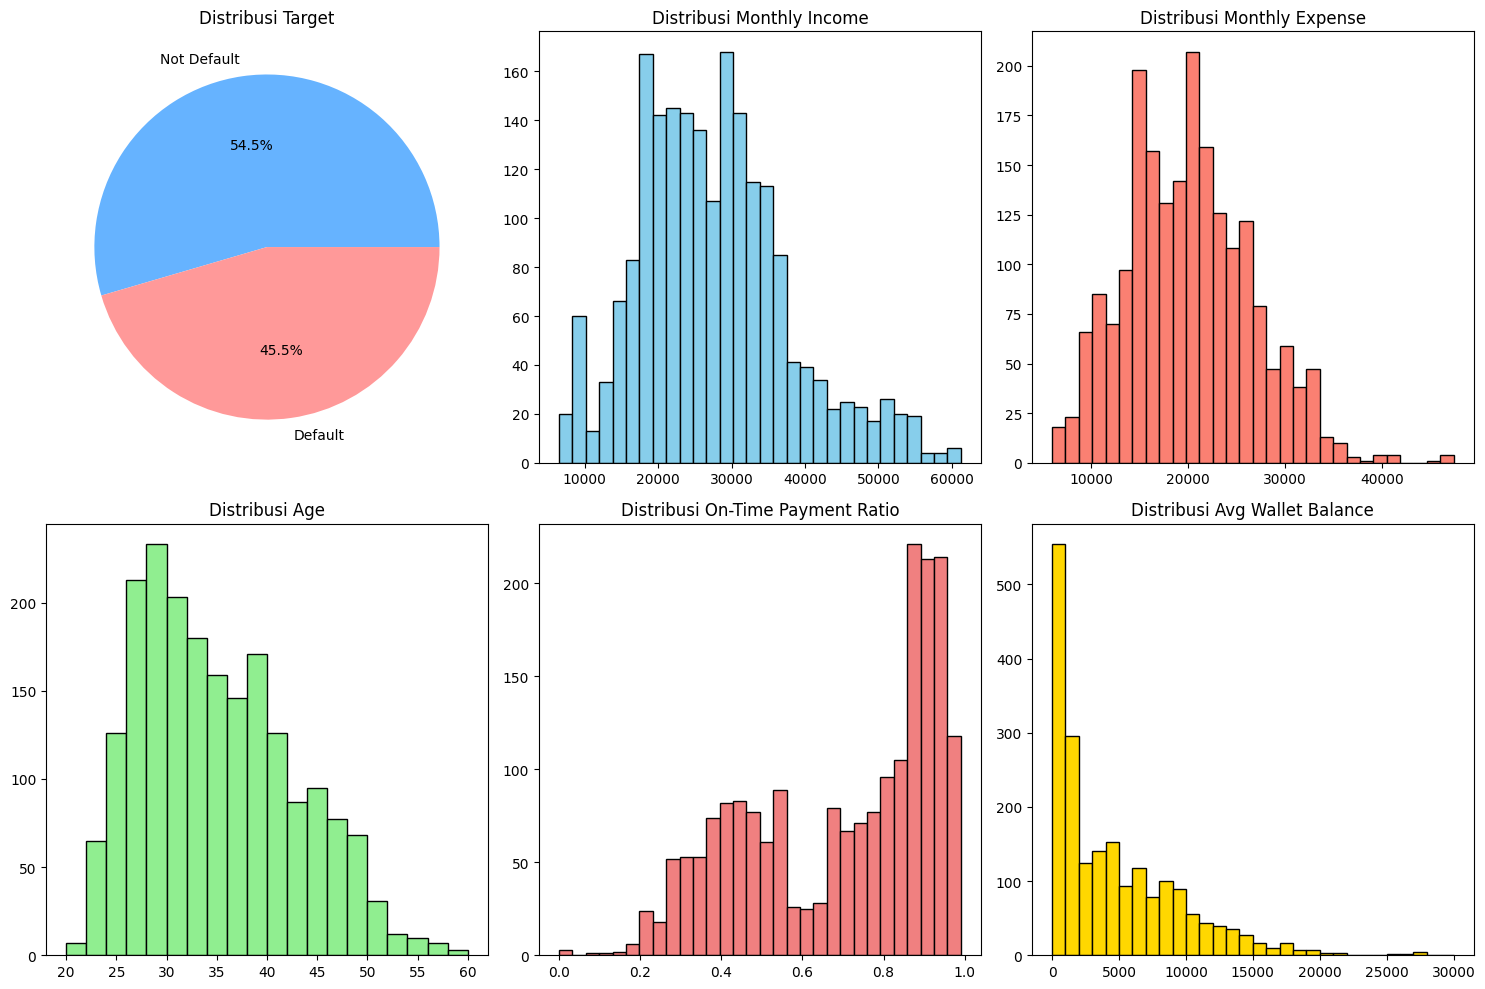

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].pie(df["target"].value_counts(), labels=["Not Default", "Default"],
               autopct="%1.1f%%", colors=["#66b3ff","#ff9999"])
axes[0, 0].set_title("Distribusi Target")

axes[0, 1].hist(df["monthly_income"], bins=30, color="skyblue", edgecolor="black")
axes[0, 1].set_title("Distribusi Monthly Income")

axes[0, 2].hist(df["monthly_expense"], bins=30, color="salmon", edgecolor="black")
axes[0, 2].set_title("Distribusi Monthly Expense")

axes[1, 0].hist(df["age"], bins=20, color="lightgreen", edgecolor="black")
axes[1, 0].set_title("Distribusi Age")

axes[1, 1].hist(df["on_time_payment_ratio"], bins=30, color="lightcoral", edgecolor="black")
axes[1, 1].set_title("Distribusi On-Time Payment Ratio")

axes[1, 2].hist(df["avg_wallet_balance"], bins=30, color="gold", edgecolor="black")
axes[1, 2].set_title("Distribusi Avg Wallet Balance")

plt.tight_layout()
plt.show()

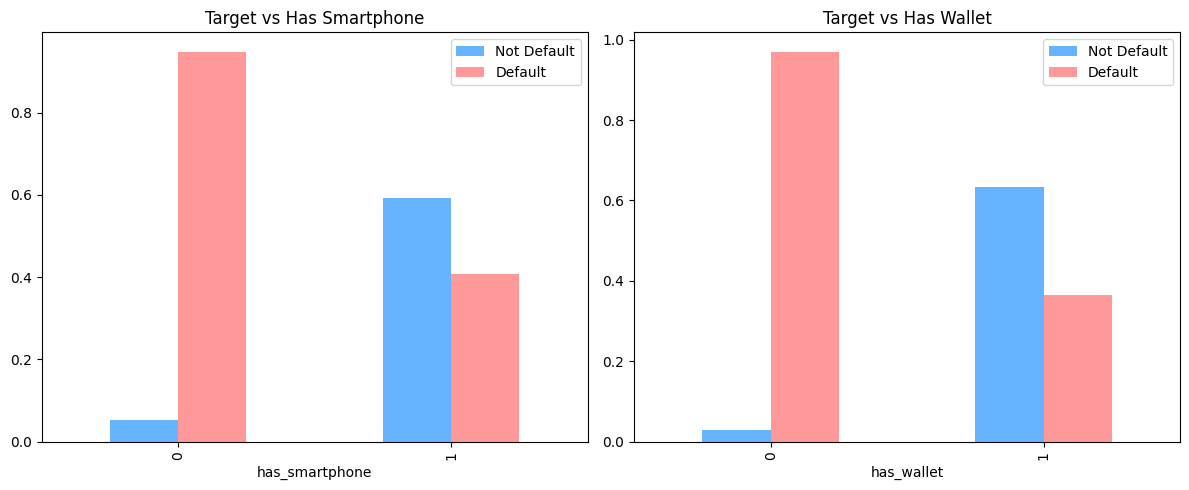

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

smartphone_cross = pd.crosstab(df["has_smartphone"], df["target"], normalize="index")
smartphone_cross.plot(kind="bar", ax=axes[0], color=["#66b3ff","#ff9999"])
axes[0].set_title("Target vs Has Smartphone")
axes[0].legend(["Not Default", "Default"])

wallet_cross = pd.crosstab(df["has_wallet"], df["target"], normalize="index")
wallet_cross.plot(kind="bar", ax=axes[1], color=["#66b3ff","#ff9999"])
axes[1].set_title("Target vs Has Wallet")
axes[1].legend(["Not Default", "Default"])

plt.tight_layout()
plt.show()

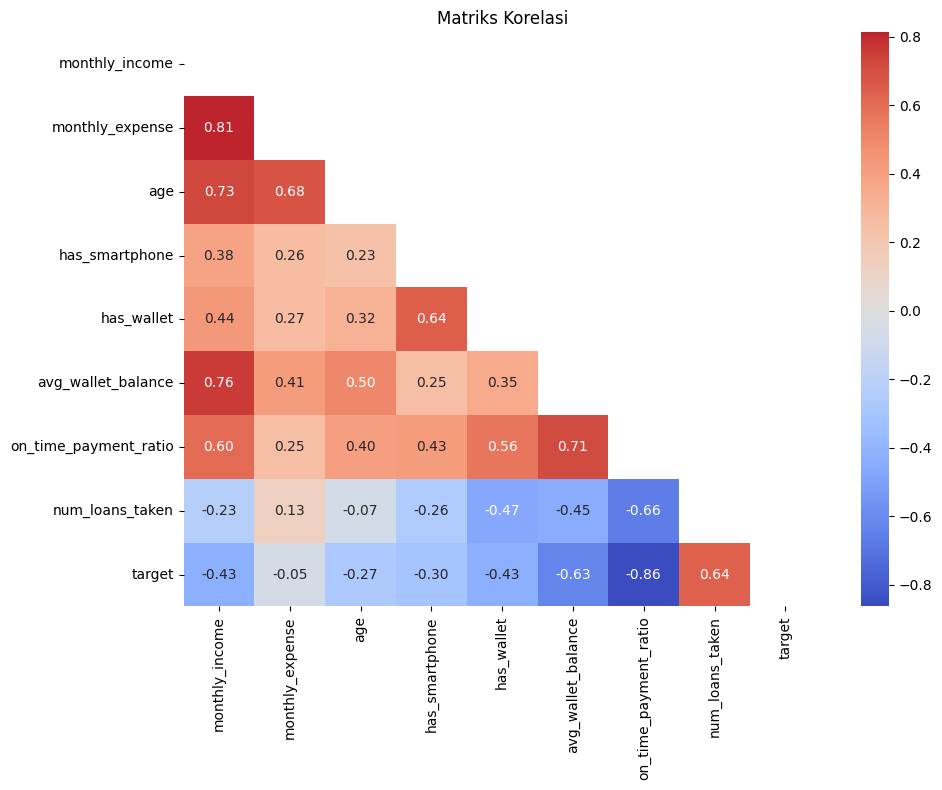

Korelasi dengan target:
target                   1.000000
num_loans_taken          0.640154
monthly_expense         -0.048684
age                     -0.272940
has_smartphone          -0.302130
has_wallet              -0.429540
monthly_income          -0.429794
avg_wallet_balance      -0.627848
on_time_payment_ratio   -0.862798
Name: target, dtype: float64


In [12]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriks Korelasi")
plt.tight_layout()
plt.show()

print("Korelasi dengan target:")
print(corr["target"].sort_values(ascending=False))

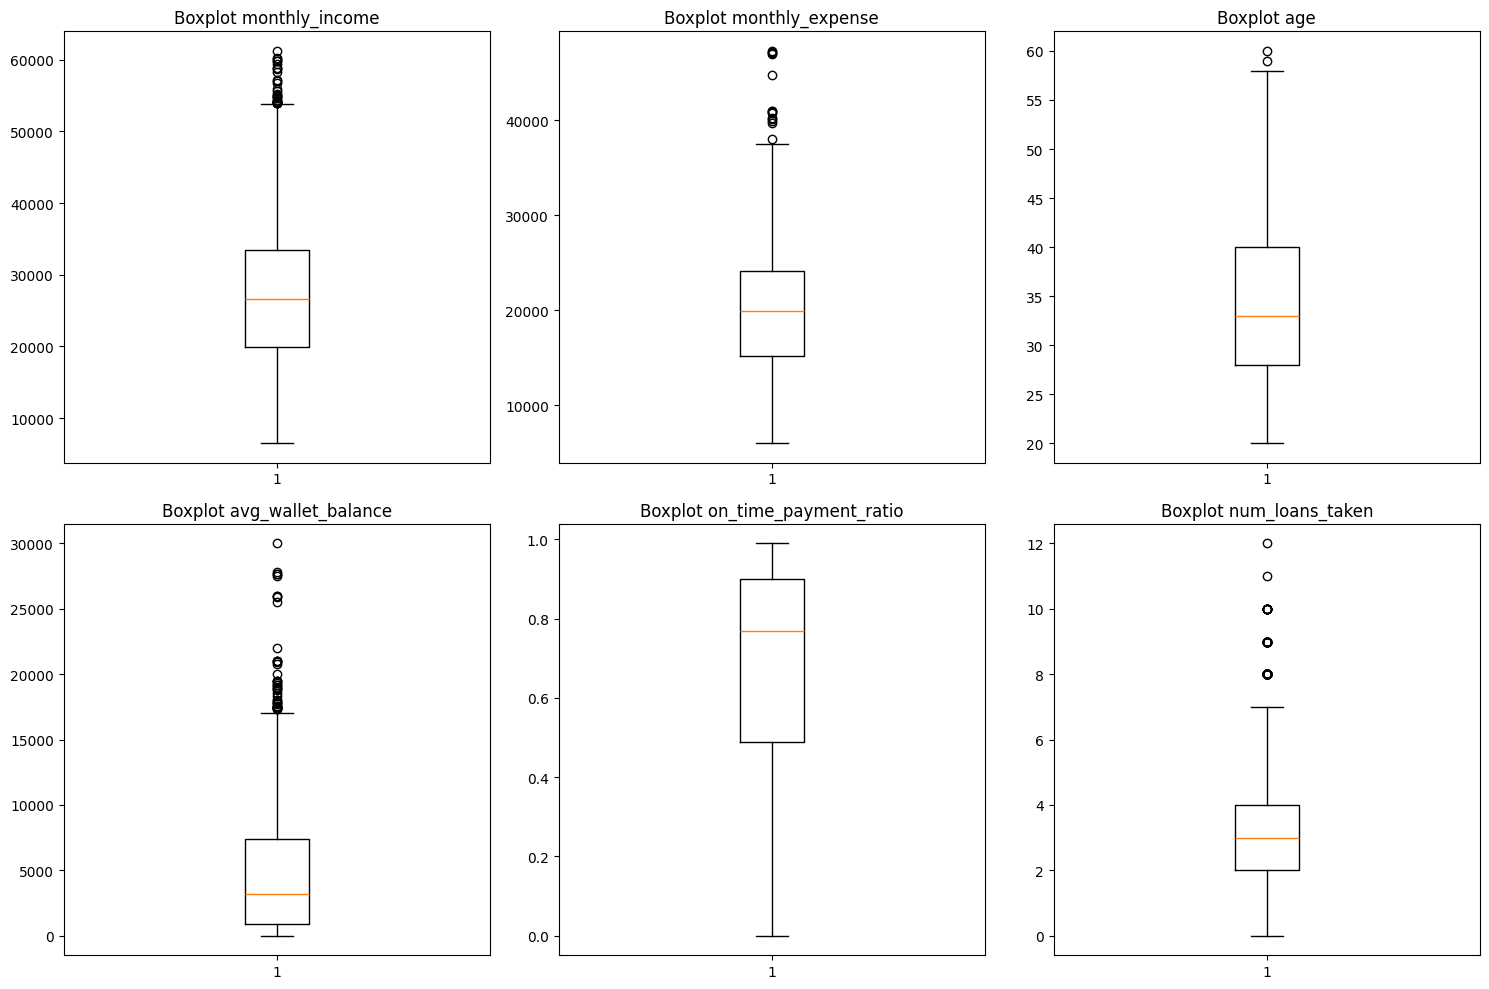

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_cols = ["monthly_income", "monthly_expense", "age",
                   "avg_wallet_balance", "on_time_payment_ratio", "num_loans_taken"]

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df[col])
    axes[row, col_idx].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

In [14]:
print("=== PREPROCESSING ===")
print(f"Missing values: {df.isnull().sum().sum()}")
print("Tidak ada missing values pada dataset.")

print(f"Duplikat sebelum: {df.duplicated().sum()}")
df_clean = df.drop_duplicates()
print(f"Duplikat setelah: {df_clean.duplicated().sum()}")

print(f"Shape sebelum: {df.shape}")
print(f"Shape setelah: {df_clean.shape}")

=== PREPROCESSING ===
Missing values: 0
Tidak ada missing values pada dataset.
Duplikat sebelum: 0
Duplikat setelah: 0
Shape sebelum: (2019, 9)
Shape setelah: (2019, 9)


In [15]:
def handle_outliers_iqr(data, columns):
    processed = data.copy()
    for col in columns:
        Q1 = processed[col].quantile(0.25)
        Q3 = processed[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((processed[col] < lower) | (processed[col] > upper)).sum()
        processed[col] = processed[col].clip(lower, upper)
        if outliers > 0:
            print(f"  {col}: {outliers} outliers ditangani")
    return processed

numerical_cols = ["monthly_income", "monthly_expense", "age",
                   "avg_wallet_balance", "on_time_payment_ratio", "num_loans_taken"]
df_clean = handle_outliers_iqr(df_clean, numerical_cols)

  monthly_income: 33 outliers ditangani
  monthly_expense: 14 outliers ditangani
  age: 2 outliers ditangani
  avg_wallet_balance: 45 outliers ditangani
  num_loans_taken: 130 outliers ditangani


In [16]:
scaler = StandardScaler()
cols_to_scale = ["monthly_income", "monthly_expense",
                  "avg_wallet_balance", "on_time_payment_ratio", "num_loans_taken"]
df_scaled = df_clean.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("Feature scaling selesai.")
print(df_scaled[cols_to_scale].describe())

Feature scaling selesai.
       monthly_income  monthly_expense  avg_wallet_balance  \
count    2.019000e+03     2.019000e+03        2.019000e+03   
mean    -5.630849e-17     2.533882e-16       -5.630849e-17   
std      1.000248e+00     1.000248e+00        1.000248e+00   
min     -2.072786e+00    -2.204266e+00       -1.037556e+00   
25%     -7.480465e-01    -7.635903e-01       -8.356757e-01   
50%     -8.424577e-02    -2.759287e-02       -3.296287e-01   
75%      5.914949e-01     6.418516e-01        6.235835e-01   
max      2.600807e+00     2.750014e+00        2.812472e+00   

       on_time_payment_ratio  num_loans_taken  
count           2.019000e+03      2019.000000  
mean           -1.689255e-16         0.000000  
std             1.000248e+00         1.000248  
min            -3.032911e+00        -1.579989  
25%            -9.007612e-01        -0.562121  
50%             3.176102e-01        -0.053187  
75%             8.832826e-01         0.455747  
max             1.274902e+00    

In [17]:
output_path = "loan_default_preprocessed.csv"
df_scaled.to_csv(output_path, index=False)
print(f"Dataset preprocessed disimpan ke: {output_path}")
print(f"Shape akhir: {df_scaled.shape}")
df_scaled.head()

Dataset preprocessed disimpan ke: loan_default_preprocessed.csv
Shape akhir: (2019, 9)


,monthly_income,monthly_expense,age,has_smartphone,has_wallet,avg_wallet_balance,on_time_payment_ratio,num_loans_taken,target
0,-0.628055,-1.283017,27,1,1,1.555262,0.709230,-0.053187,0
1,2.312917,-0.085376,43,1,1,-0.411727,0.709230,0.455747,0
2,-0.775775,-1.832822,50,1,1,-0.189658,0.535177,-0.053187,0
3,1.831274,0.749746,46,1,1,1.240104,0.839769,-0.562121,0
4,0.932819,0.477427,34,1,1,0.791256,1.144362,-1.579989,0


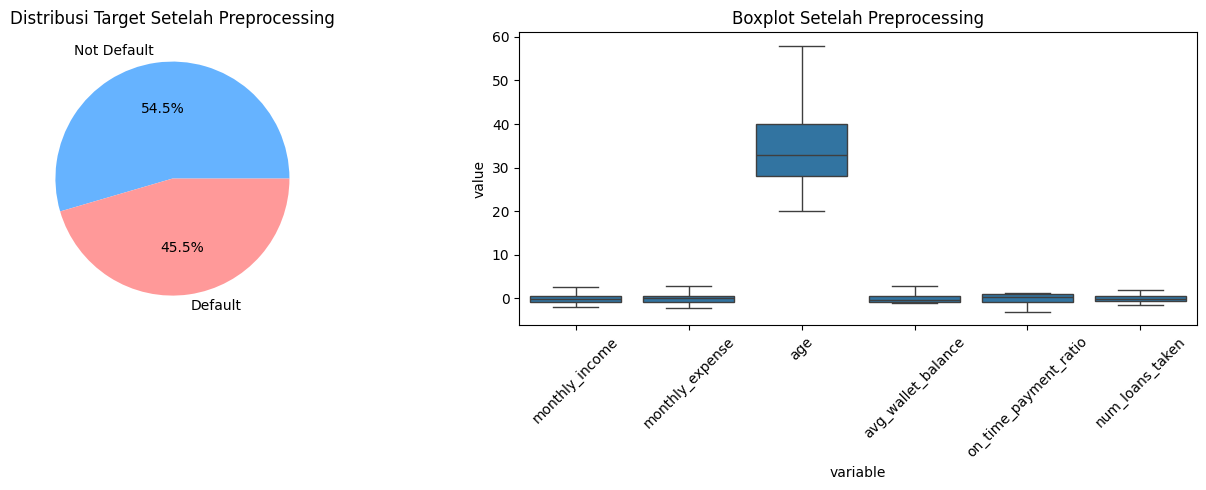

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(df_scaled["target"].value_counts(), labels=["Not Default", "Default"],
            autopct="%1.1f%%", colors=["#66b3ff","#ff9999"])
axes[0].set_title("Distribusi Target Setelah Preprocessing")

df_melt = df_scaled[numerical_cols].melt()
sns.boxplot(data=df_melt, x="variable", y="value", ax=axes[1])
axes[1].set_title("Boxplot Setelah Preprocessing")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()